# 01 — Exploration des données (EDA)

**Projet** : Prédiction d'attrition client (churn télécom) avec scikit-learn
**Cas métier** : Identifier, avant la résiliation, les abonnés les plus susceptibles de partir dans les 30 prochains jours, afin de cibler une action de rétention (offre, geste commercial, appel sortant) sur une population réduite et pertinente.
**Jeu de données** : `telecom_churn` — Abonnés télécom et attrition (churn)

> Population d'abonnés d'un opérateur télécom, avec leurs caractéristiques contractuelles, d'usage et de relation client, et l'étiquette d'attrition observée. Les données sont générées par un modèle logistique latent avec interactions : le signal est réel mais bruité, ce qui reproduit fidèlement la difficulté d'un cas churn industriel.

## Objectifs pédagogiques

1. Charger un jeu de données tabulaire et en établir le profil (types, manquants, doublons).
1. Lire une distribution : détecter déséquilibre, outliers et colinéarité **avant** de modéliser.
1. Relier chaque observation statistique à une conséquence métier ou de modélisation.
1. Produire les figures qui serviront de référence dans les notebooks suivants.

**Objectifs transverses du dépôt**

- Composer un pipeline scikit-learn propre : ColumnTransformer, transformers custom, fit sur le train uniquement.
- Utiliser une classe abstraite BaseModel pour rendre le framework interchangeable.
- Lire des métriques de classification en contexte déséquilibré (ROC AUC, PR AUC, rappel, précision).

## 0. Environnement

Toute la configuration vient de **Hydra** (`conf/`) : aucune valeur métier n'est codée en dur
dans ce notebook. Si `data/raw` est vide, le générateur synthétique du projet prend le relais
(voir `make data`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Racine du projet ---------------------------------------------------------------------------
# Le notebook s'exécute depuis `notebooks/` : on remonte d'un cran pour pouvoir importer `src`.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hydra import compose, initialize_config_dir  # noqa: E402
from hydra.core.global_hydra import GlobalHydra  # noqa: E402
from loguru import logger  # noqa: E402

from src.schemas.config import validate_config  # noqa: E402
from src.utils.paths import ProjectPaths  # noqa: E402

# --- Réglages d'affichage -----------------------------------------------------------------------
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
logger.remove()
logger.add(sys.stderr, level="WARNING")

# --- Configuration : exactement celle de `python -m src.main` ------------------------------------
# Les notebooks travaillent sur un échantillon réduit (1500 lignes) : l'exécution complète
# reste sous la minute, tout en conservant des distributions réalistes.
NB_ROWS = 1500

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(PROJECT_ROOT / "conf"), version_base=None):
    CONFIG = validate_config(
        compose(
            config_name="config",
            overrides=[
                "mode=train",
                f"data.n_samples={NB_ROWS}",
                "seed=42",
                "log_level=WARNING",
                "++train.epochs=3",
                "train.callbacks.progress_bar=false",
            ],
        )
    )

PATHS = ProjectPaths.from_root(PROJECT_ROOT)
# Les notebooks écrivent leurs artefacts dans `outputs/notebooks` (ignoré par git) afin de ne
# jamais écraser ceux produits par `make train`.
NB_PATHS = ProjectPaths.from_root(PROJECT_ROOT / "outputs" / "notebooks").ensure()

print(f"Projet            : {CONFIG.project.name}")
print(f"Tâche             : {CONFIG.metrics.task}")
print(f"Métrique primaire : {CONFIG.metrics.primary} (seuil cible : 0.7)")
print(f"Cible             : {CONFIG.data.target}")
print(f"Algorithme        : {CONFIG.model.algorithm} ({CONFIG.model.name})")
print(f"Lignes (notebook) : {NB_ROWS}")

Projet            : telecom-churn-sklearn
Tâche             : binary
Métrique primaire : roc_auc (seuil cible : 0.7)
Cible             : churned
Algorithme        : random_forest (Forêt aléatoire scikit-learn)
Lignes (notebook) : 1500


**Pourquoi ce bloc d'initialisation**

- `CONFIG` est l'objet **Pydantic** validé : une clé incohérente échoue ici, pas en production.
- Les notebooks travaillent sur un échantillon réduit pour rester rapides ; `make train` utilise `data.n_samples` complet.
- `NB_PATHS` isole les écritures du notebook dans `outputs/notebooks`.

## 1. Chargement et premier contact

On ne regarde jamais un dataset sans vérifier trois choses : sa **forme** (lignes × colonnes),
ses **types** (un numérique lu comme texte casse tout) et ses **premières lignes** (les valeurs
ont-elles du sens métier ?).

In [2]:
from src.data.generators import SyntheticDataGenerator
from src.data.loaders import RawDataLoader

raw_path = PATHS.data_file(CONFIG.data.dataset_name)
if raw_path.exists():
    # Cas nominal : le dataset a été généré par `make data`, on passe par le loader validant.
    raw = RawDataLoader(PATHS, dataset_name=CONFIG.data.dataset_name).load()
    print(f"Dataset lu depuis {raw_path.relative_to(PROJECT_ROOT)}")
else:
    # Le notebook reste exécutable sur un clone frais : on génère en mémoire.
    raw = SyntheticDataGenerator(n_samples=NB_ROWS, seed=CONFIG.data.seed).generate()
    print("data/raw vide : génération synthétique en mémoire (`make data` la persiste)")

raw = raw.head(NB_ROWS).reset_index(drop=True)
print(f"shape = {raw.shape}")
raw.head()

2026-09-13 06:04:50 | INFO     | src.data.loaders:_log_profile:183 - Loaded raw data | rows=4000 cols=15 missing_cells=317 memory=631.8 KB


Dataset lu depuis data/raw/telecom_churn.parquet
shape = (1500, 15)


,customer_id,signup_date,tenure_months,contract_type,internet_service,payment_method,region,monthly_charges,total_charges,support_tickets_6m,avg_monthly_data_gb,num_products,has_promotion,satisfaction_score,churned
0,CUS-00001,2024-12-21,13,two_year,dsl,electronic_check,south,51.89,680.43,1,83.89,2,0,7.57,0
1,CUS-00002,2022-05-03,45,two_year,dsl,credit_card,south,40.44,1849.09,0,138.90,3,0,7.41,0
2,CUS-00003,2023-07-21,30,two_year,none,mailed_check,west,20.11,606.84,1,3.18,5,0,7.48,0
3,CUS-00004,2025-12-01,2,month_to_month,dsl,credit_card,west,49.56,100.25,0,54.37,3,1,5.78,1
4,CUS-00005,2025-08-12,5,month_to_month,fiber,electronic_check,west,84.84,406.24,1,161.71,3,0,5.67,1


**Ce qu'il faut retenir**

- Le contrat `telecom_churn` est documenté dans `data/README.md` : chaque colonne y a une signification métier.
- Les identifiants et horodatages ne sont **pas** des features : ils servent à tracer et à splitter.

In [3]:
from src.data.schemas import describe_schema, validation_report

# Types déclarés (contrat Pandera) vs types réellement lus : toute divergence est un signal.
contract = describe_schema("raw")
observed = pd.DataFrame({"dtype_lu": {str(k): str(v) for k, v in raw.dtypes.items()}})
contract.join(observed)[["dtype", "dtype_lu", "nullable", "unique", "checks"]]

,dtype,dtype_lu,nullable,unique,checks
column,,,,,
customer_id,string[pyarrow],str,False,False,<Check str_matches: str_matches('^CUS-[0-9]{5}...
signup_date,datetime64[ns],datetime64[ns],False,False,
tenure_months,int64,int64,False,False,<Check greater_than_or_equal_to: greater_than_...
contract_type,string[pyarrow],str,False,False,"<Check isin: isin(['month_to_month', 'one_year..."
internet_service,string[pyarrow],str,False,False,"<Check isin: isin(['fiber', 'dsl', 'none'])>"
payment_method,string[pyarrow],str,False,False,"<Check isin: isin(['electronic_check', 'mailed..."
region,string[pyarrow],str,False,False,"<Check isin: isin(['north', 'south', 'east', '..."
monthly_charges,float64,float64,False,False,<Check greater_than_or_equal_to: greater_than_...
total_charges,float64,float64,False,False,<Check greater_than_or_equal_to: greater_than_...


**Ce qu'il faut retenir**

- La colonne `dtype` vient du **contrat**, `dtype_lu` de la source : elles doivent correspondre.
- Les `checks` (bornes, valeurs autorisées) sont la mémoire des règles métier — ils seront testés au notebook 02.

In [4]:
report = validation_report(raw)
summary = pd.DataFrame(
    {
        "indicateur": [
            "lignes",
            "colonnes",
            "cellules manquantes",
            "taux de manquants",
            "mémoire (Ko)",
        ],
        "valeur": [
            report["n_rows"],
            report["n_columns"],
            report["missing_cells"],
            f"{report['missing_rate']:.2%}",
            round(report["memory_kb"], 1),
        ],
    }
)
summary

,indicateur,valeur
0,lignes,1500
1,colonnes,15
2,cellules manquantes,112
3,taux de manquants,0.50%
4,mémoire (Ko),237.3


**Ce qu'il faut retenir**

- Un taux de manquants global faible peut cacher une colonne très incomplète : regarder **par colonne**.
- La mémoire indique si le dataset tient en RAM (sinon : pyarrow, chunking ou échantillonnage).

## 2. Valeurs manquantes

Où, combien, et surtout : **manquant au hasard ou pas** ? Un manquant informatif (ex. score de satisfaction non renseigné par les clients mécontents) est un signal, pas seulement un problème technique.

In [5]:
missing = raw.isna().sum()
missing_frame = (
    pd.DataFrame({"manquants": missing, "taux": (missing / len(raw)).round(4)})
    .loc[lambda frame: frame["manquants"] > 0]
    .sort_values("manquants", ascending=False)
)
missing_frame

,manquants,taux
satisfaction_score,68,0.0453
avg_monthly_data_gb,44,0.0293


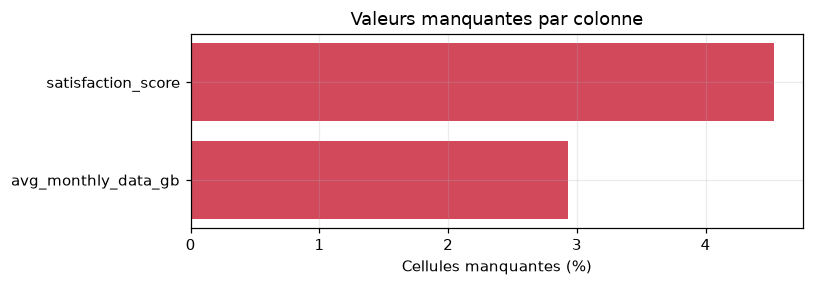

In [6]:
if missing_frame.empty:
    print("Aucune valeur manquante dans cet échantillon.")
else:
    fig, axis = plt.subplots(figsize=(7.5, 0.55 * len(missing_frame) + 1.6))
    axis.barh(missing_frame.index[::-1], missing_frame["taux"][::-1] * 100, color="#d1495b")
    axis.set_xlabel("Cellules manquantes (%)")
    axis.set_title("Valeurs manquantes par colonne")
    fig.tight_layout()
    plt.show()

**Ce qu'il faut retenir**

- L'imputation doit être **apprise sur le train** (moyenne/médiane/constante) puis appliquée aux autres splits.
- Ajouter un indicateur binaire « valeur manquante » est souvent rentable quand le manquant est informatif.
- Notes du générateur : Valeurs manquantes volontaires sur `satisfaction_score` (~5 %) et `avg_monthly_data_gb` (~3 %) pour exercer l'imputation.; Outliers légitimes (~1 % des lignes) : clients entreprise avec charges élevées et accumulation de tickets..

## 3. Distributions numériques

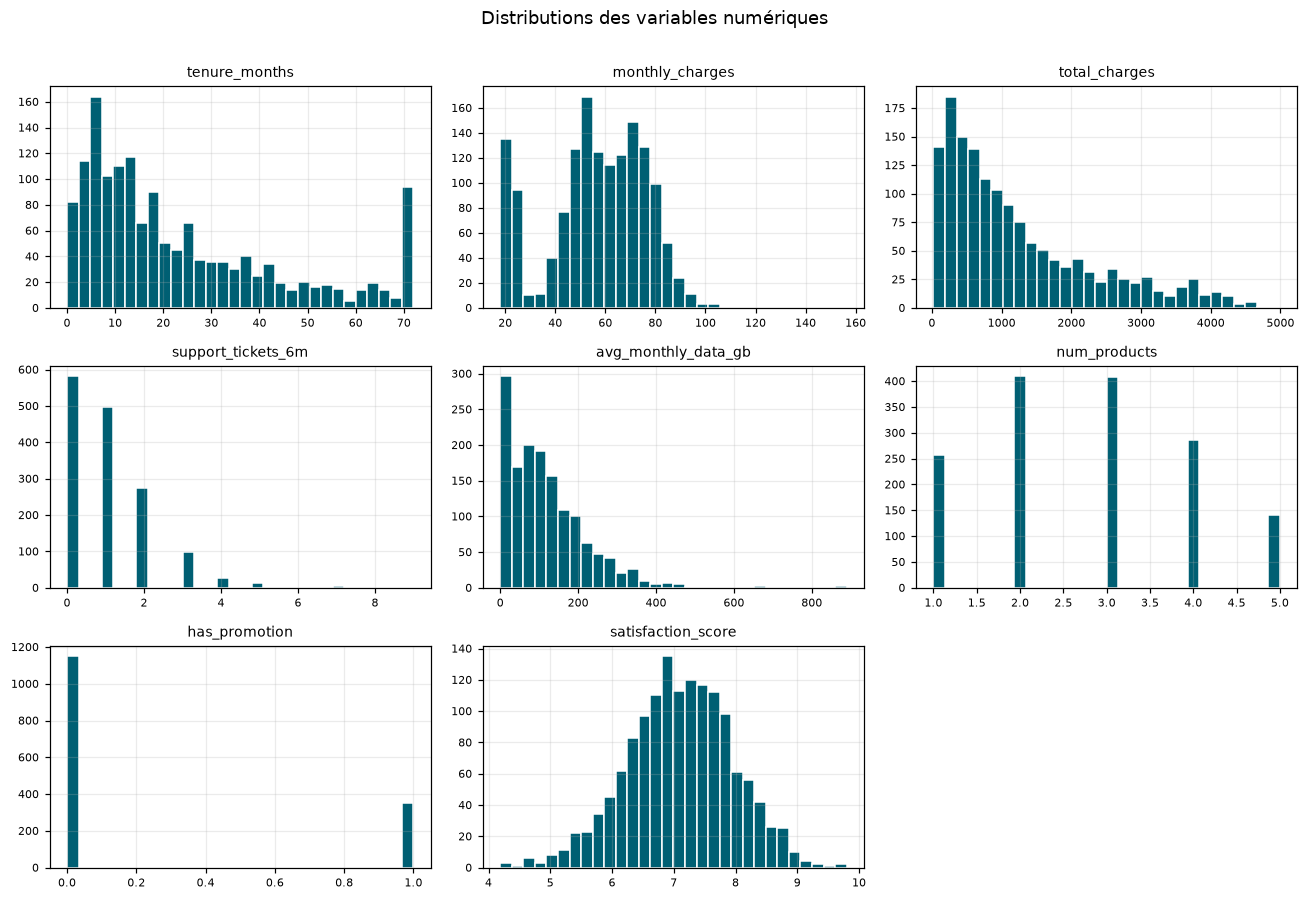

In [7]:
numeric_columns = [column for column in raw.columns if pd.api.types.is_numeric_dtype(raw[column])]
numeric_columns = [column for column in numeric_columns if column != CONFIG.data.target]

n_plots = len(numeric_columns)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols)) if n_plots else 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 2.7 * n_rows))
for axis, column in zip(np.atleast_1d(axes).ravel(), numeric_columns, strict=False):
    raw[column].hist(bins=30, ax=axis, color="#005f73", edgecolor="white")
    axis.set_title(column, fontsize=9)
    axis.tick_params(labelsize=7)
for axis in np.atleast_1d(axes).ravel()[len(numeric_columns) :]:
    axis.axis("off")
fig.suptitle("Distributions des variables numériques", y=1.005)
fig.tight_layout()
plt.show()

In [8]:
raw[numeric_columns].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2)

,count,mean,std,min,1%,25%,50%,75%,99%,max
tenure_months,1500.0,23.49,20.40,0.00,1.00,8.00,16.00,34.00,72.00,72.00
monthly_charges,1500.0,56.79,20.18,18.00,18.00,46.31,57.84,71.54,95.96,156.41
total_charges,1500.0,1228.97,1070.53,21.92,52.73,394.45,883.42,1758.49,4259.00,4991.92
support_tickets_6m,1500.0,1.05,1.17,0.00,0.00,0.00,1.00,2.00,5.00,9.00
avg_monthly_data_gb,1456.0,118.10,106.47,0.00,0.03,41.23,99.00,170.56,443.98,889.54
num_products,1500.0,2.76,1.21,1.00,1.00,2.00,3.00,4.00,5.00,5.00
has_promotion,1500.0,0.23,0.42,0.00,0.00,0.00,0.00,0.00,1.00,1.00
satisfaction_score,1432.0,7.10,0.85,4.19,4.97,6.56,7.12,7.69,8.98,9.80


**Ce qu'il faut retenir**

- Une distribution très asymétrique (max ≫ p99) justifie un **winsorising** ou un `log1p` plutôt qu'une suppression d'outliers.
- Des échelles hétérogènes (euros, Go, unités) imposent un **scaling** pour les modèles sensibles à la distance (SVM, k-NN, réseaux).
- Comparer `mean` et `50%` : un écart important signale une queue lourde.

## 4. Variables catégorielles

In [9]:
categorical_columns = [
    column
    for column in raw.columns
    if not pd.api.types.is_numeric_dtype(raw[column])
    and column not in [*CONFIG.data.drop_columns, str(CONFIG.data.target)]
]

for column in categorical_columns:
    counts = raw[column].astype(str).value_counts()
    print(f"--- {column} ({len(counts)} modalités) ---")
    print((counts / len(raw)).map("{:.1%}".format).to_string())

--- contract_type (3 modalités) ---
contract_type
month_to_month    44.4%
two_year          31.1%
one_year          24.5%
--- internet_service (3 modalités) ---
internet_service
fiber    53.7%
dsl      30.2%
none     16.1%
--- payment_method (4 modalités) ---
payment_method
electronic_check    35.5%
bank_transfer       27.7%
credit_card         22.3%
mailed_check        14.6%
--- region (4 modalités) ---
region
north    27.5%
east     25.3%
south    24.3%
west     22.9%


**Ce qu'il faut retenir**

- Une modalité ultra-rare (< 1 %) doit être regroupée dans un bucket `rare` : sinon l'encodage one-hot crée des colonnes quasi vides et instables.
- Une cardinalité élevée (identifiants, codes postaux) appelle un **target encoding** régularisé plutôt qu'un one-hot.

## 5. La cible

taux de classe positive attendu ≈ 26%. C'est la variable la plus importante du notebook : son déséquilibre conditionne le choix des métriques.

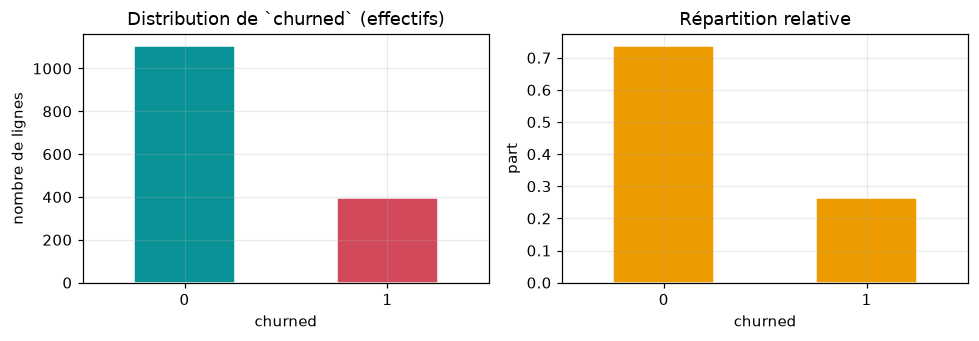

classes : [0, 1]
classe majoritaire : 73.7% -> accuracy triviale


In [10]:
target = CONFIG.data.target
distribution = raw[target].value_counts(normalize=True).sort_index()
counts = raw[target].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.2))
counts.plot.bar(
    ax=axes[0], color=["#0a9396", "#d1495b"] if len(counts) == 2 else "#0a9396", edgecolor="white"
)
axes[0].set_title(f"Distribution de `{target}` (effectifs)")
axes[0].set_ylabel("nombre de lignes")
distribution.plot.bar(ax=axes[1], color="#ee9b00", edgecolor="white")
axes[1].set_title("Répartition relative")
axes[1].set_ylabel("part")
for axis in axes:
    axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

print(f"classes : {list(counts.index)}")
print(f"classe majoritaire : {float(distribution.max()):.1%} -> accuracy triviale")

**Ce qu'il faut retenir**

- L'accuracy d'un modèle « classe majoritaire » est déjà élevée : ce n'est **pas** une preuve de performance.
- En déséquilibre, piloter sur le **rappel de la classe positive** et le **PR AUC** plutôt que sur l'accuracy ou le ROC AUC.
- Le ré-échantillonnage (SMOTE, pondération) se décide ici, et s'applique **uniquement sur le train**.

In [11]:
# Signal par variable catégorielle : écart de taux de cible entre modalités.
target = CONFIG.data.target
rows = []
for column in categorical_columns:
    grouped = raw.groupby(raw[column].astype(str))[target].agg(["mean", "count"])
    if grouped.empty or grouped["mean"].nunique() < 2:
        continue
    spread = float(grouped["mean"].max() - grouped["mean"].min())
    rows.append(
        {
            "variable": column,
            "écart_de_taux": round(spread, 4),
            "modalité_la_plus_risquée": grouped["mean"].idxmax(),
            "taux_max": round(float(grouped["mean"].max()), 4),
            "modalité_la_moins_risquée": grouped["mean"].idxmin(),
            "taux_min": round(float(grouped["mean"].min()), 4),
        }
    )
signal_frame = pd.DataFrame(rows).sort_values("écart_de_taux", ascending=False)
signal_frame

,variable,écart_de_taux,modalité_la_plus_risquée,taux_max,modalité_la_moins_risquée,taux_min
0,contract_type,0.3454,month_to_month,0.4489,one_year,0.1035
1,internet_service,0.2346,fiber,0.3379,none,0.1033
2,payment_method,0.0518,mailed_check,0.2831,bank_transfer,0.2313
3,region,0.0366,west,0.2820,east,0.2454


**Ce qu'il faut retenir**

- Un écart de taux important entre modalités = signal exploitable directement par le modèle.
- Un écart proche de 0 ne veut pas dire « inutile » : la variable peut interagir avec une autre.
- Ces écarts se lisent en **points de pourcentage** : les présenter ainsi aux métiers évite les malentendus.

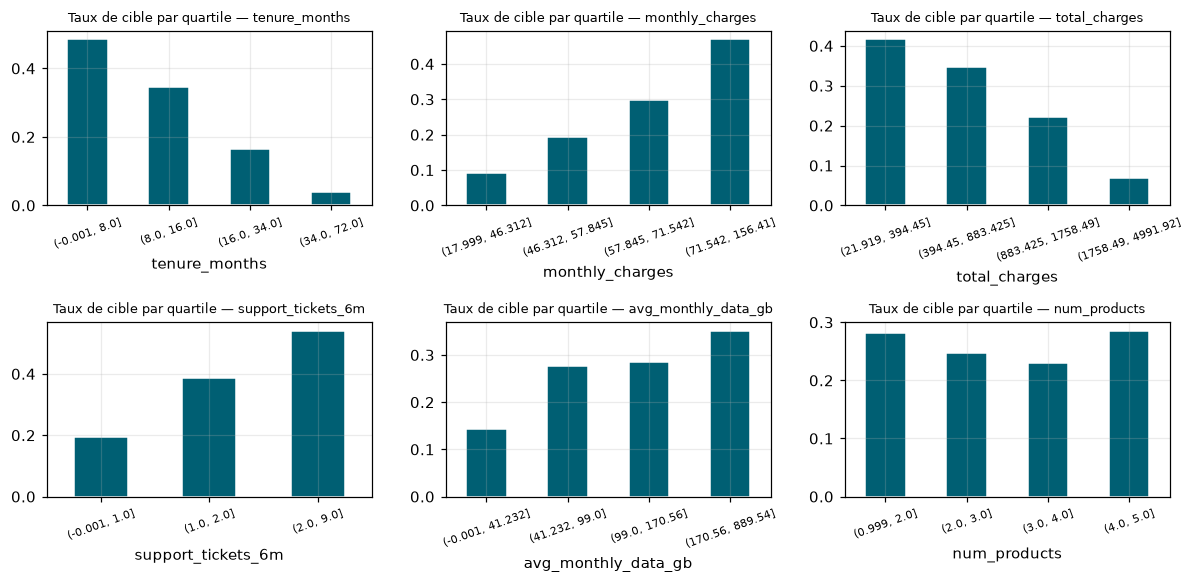

In [12]:
# Signal par variable numérique : taux de cible par quartile.
target = CONFIG.data.target
plots = [column for column in numeric_columns if raw[column].nunique() > 4][:6]
fig, axes = plt.subplots(2, 3, figsize=(11.0, 5.4))
for axis, column in zip(np.atleast_1d(axes).ravel(), plots, strict=False):
    buckets = pd.qcut(raw[column], q=4, duplicates="drop")
    grouped = raw.groupby(buckets, observed=True)[target].mean()
    grouped.plot.bar(ax=axis, color="#005f73", edgecolor="white")
    axis.set_title(f"Taux de cible par quartile — {column}", fontsize=8.5)
    axis.set_ylabel("")
    axis.tick_params(labelsize=7, axis="x", rotation=20)
for axis in np.atleast_1d(axes).ravel()[len(plots) :]:
    axis.axis("off")
fig.tight_layout()
plt.show()

**Ce qu'il faut retenir**

- Une relation **monotone** (le taux monte avec la variable) est facilement apprise, y compris par un modèle linéaire.
- Une relation en **U** impose des transformations (binning, splines) ou un modèle non linéaire.
- Le binning par quantiles est aussi une feature déclarée dans `conf/preprocessing/default.yaml` (recette `bin`).

## 6. Colinéarité et structure

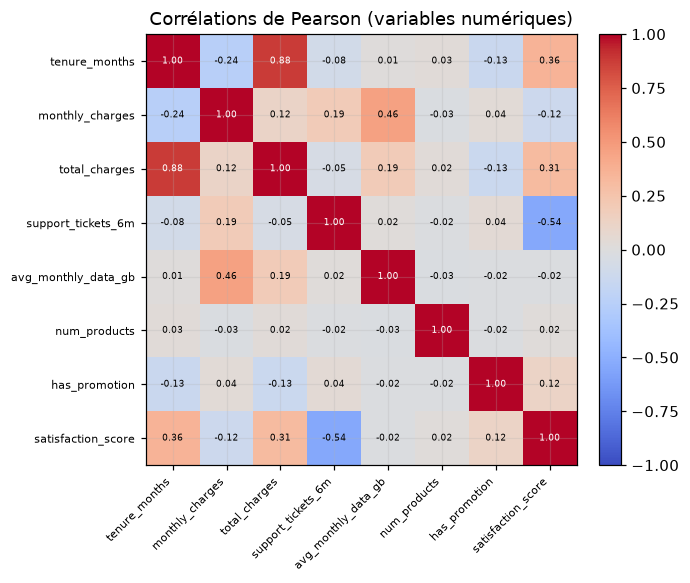

In [13]:
correlation = raw[numeric_columns].corr(numeric_only=True)
fig, axis = plt.subplots(figsize=(6.6, 5.4))
image = axis.imshow(correlation.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(
    range(len(correlation.columns)), correlation.columns, rotation=45, ha="right", fontsize=7
)
axis.set_yticks(range(len(correlation.index)), correlation.index, fontsize=7)
for row in range(correlation.shape[0]):
    for column in range(correlation.shape[1]):
        value = correlation.iloc[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="black" if abs(value) < 0.6 else "white",
        )
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
axis.set_title("Corrélations de Pearson (variables numériques)")
fig.tight_layout()
plt.show()

**Ce qu'il faut retenir**

- Deux features corrélées à > 0.9 n'apportent presque rien ensemble : en garder une simplifie le modèle et son explication.
- Les arbres sont robustes à la colinéarité ; les modèles linéaires/régularisés voient leurs coefficients devenir instables.
- La corrélation ne capture pas les relations **non linéaires** : la vérifier par des graphes cible vs feature.

In [14]:
# Outliers : comptage par la règle de l'IQR (1.5 x écart interquartile).
rows = []
for column in numeric_columns:
    series = raw[column].dropna()
    if series.empty:
        continue
    low, high = series.quantile([0.25, 0.75])
    iqr = high - low
    outliers = int(((series < low - 1.5 * iqr) | (series > high + 1.5 * iqr)).sum())
    rows.append(
        {"colonne": column, "outliers_iqr": outliers, "part": outliers / max(len(series), 1)}
    )
outlier_frame = pd.DataFrame(rows).sort_values("outliers_iqr", ascending=False)
outlier_frame.head(8).round(4)

,colonne,outliers_iqr,part
6,has_promotion,351,0.2340
2,total_charges,50,0.0333
4,avg_monthly_data_gb,32,0.0220
7,satisfaction_score,16,0.0112
3,support_tickets_6m,9,0.0060
1,monthly_charges,6,0.0040
0,tenure_months,0,0.0000
5,num_products,0,0.0000


**Ce qu'il faut retenir**

- La règle IQR **signale**, elle ne tranche pas : un outlier peut être un client légitime (grand compte, pic saisonnier).
- Le winsorising (clip aux quantiles 1-99 %) conserve les lignes et les labels, contrairement à la suppression.

In [15]:
# Intégrité : unicité de la clé et doublons complets.
key = CONFIG.data.id_column
duplicates = int(raw.duplicated().sum())
key_duplicates = int(raw[key].duplicated().sum()) if key and key in raw.columns else 0
print(f"doublons complets            : {duplicates}")
print(f"doublons sur la clé '{key}' : {key_duplicates}")
unique_keys = raw[key].nunique() if key in raw.columns else "n/a"
print(f"identifiants uniques         : {unique_keys} / {len(raw)}")

doublons complets            : 0
doublons sur la clé 'customer_id' : 0
identifiants uniques         : 1500 / 1500


## 7. Synthèse de l'exploration

**Lectures clés de ce jeu de données**

- La classe cible est déséquilibrée (~26 % de churn) : l'accuracy seule est trompeuse, il faut piloter ROC/PR AUC, rappel et précision.
- `contract_type = month_to_month` est de loin le premier facteur de risque : sans engagement, la résiliation est structurellement plus facile.
- L'ancienneté (`tenure_months`) est fortement protectrice : le risque décroît régulièrement au-delà de 12 mois, d'où l'intérêt des features de cohorte.
- `total_charges` et `monthly_charges × tenure` sont quasi redondants : colinéarité attendue, à surveiller pour les modèles linéaires (pas gênant pour les arbres).
- Le nombre de tickets support sur 6 mois est un signal d'alerte précoce : au-delà de 4 tickets, la probabilité de départ progresse nettement.
- `satisfaction_score` est anti-corrélé au churn mais comporte ~5 % de manquants : l'imputation doit être explicite et documentée (médiane par contrat).
- Le paiement par `electronic_check` est associé à un churn supérieur : proxy d'un client peu engagé dans la relation, pas d'une cause directe.
- La fibre (`internet_service = fiber`) présente des charges plus élevées et un churn plus fort : le prix perçu est un levier de rétention.
- Quelques outliers légitimes existent (charges > 250 EUR, > 8 tickets) : les supprimer perdrait de l'information, le winsorising (1-99 %) est préférable.
- Les distributions numériques sont hétérogènes (charges en EUR, consommation en Go, tickets en unités) : le scaling est indispensable pour les modèles sensibles à l'échelle (SVM, k-NN, réseaux).
- La variable `region` n'apporte presque aucun signal : candidate à l'élimination pour simplifier le modèle (test de permutation importance).
- Les interactions comptent : contrat mensuel + faible ancienneté + satisfaction basse concentre l'essentiel du risque, ce qu'un modèle linéaire sans terme d'interaction rate.
- Le bruit injecté (probabilité de churn non déterministe) fixe un plafond de performance : un AUC de 1.0 signerait une fuite de données, pas un bon modèle.

### Décisions de modélisation issues de l'EDA

| Observation | Décision |
| --- | --- |
| Valeurs manquantes localisées | Imputation apprise sur le train (notebook 03) |
| Échelles hétérogènes | Scaling numérique obligatoire |
| Outliers légitimes | Winsorising plutôt que suppression |
| Modalités rares | Regroupement `rare` avant encodage |
| Colinéarité | Surveiller l'importance des features (notebook 04) |

**Suite** : `02_validation.ipynb` transforme ces observations en **contrats exécutables** (Pandera).